<a href="https://colab.research.google.com/github/Anisha02-jn/AI_BugFixing/blob/main/RoadDamage_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aliabdelmenam/rdd-2022")

print("Path to dataset files:", path)

100%|██████████| 9.90G/9.90G [08:28<00:00, 20.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1


In [6]:
!pip install -q ultralytics opencv-python matplotlib pandas seaborn pyyaml scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 9.6 MB/s eta 0:00:00


In [7]:
import os
import glob
import json
import shutil
import random
import math
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

from sklearn.model_selection import train_test_split

from ultralytics import YOLO

print("Libraries imported successfully.")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Libraries imported successfully.


In [8]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not available.")
    print("Go to Runtime → Change runtime type → T4 GPU")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [9]:
import os

print("Dataset path:")
print(path)

print("\nFiles and folders:")
for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)

    if level <= 3:
        indent = "  " * level
        print(f"{indent}{os.path.basename(root)}/")

        for file in files[:10]:
            print(f"{indent}  {file}")

Dataset path:
/root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1

Files and folders:
1/
  RDD_SPLIT/
    test/
      labels/
        China_Drone_001930.txt
        Czech_000735.txt
        Japan_006039.txt
        Norway_007918.txt
        India_001714.txt
        Czech_001536.txt
        India_004389.txt
        Norway_002907.txt
        Japan_010290.txt
        China_Drone_000985.txt
      images/
        Norway_004021.jpg
        Japan_007360.jpg
        Norway_001028.jpg
        Japan_012303.jpg
        Japan_002973.jpg
        Czech_002130.jpg
        India_009315.jpg
        India_006797.jpg
        India_002065.jpg
        Norway_007464.jpg
    train/
      labels/
        Japan_004155.txt
        United_States_003030.txt
        China_MotorBike_001649.txt
        Norway_004488.txt
        Japan_009082.txt
        India_004949.txt
        Norway_004605.txt
        Japan_003321.txt
        United_States_004223.txt
        Japan_004918.txt
      images/
        Chin

In [10]:
import glob

image_extensions = [
    "*.jpg",
    "*.jpeg",
    "*.png",
    "*.JPG",
    "*.JPEG",
    "*.PNG"
]

image_files = []

for ext in image_extensions:
    image_files.extend(
        glob.glob(
            os.path.join(path, "**", ext),
            recursive=True
        )
    )

image_files = sorted(set(image_files))

print("Total images found:", len(image_files))

print("\nFirst 20 images:")
for image in image_files[:20]:
    print(image)

Total images found: 38385

First 20 images:
/root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT/test/images/China_Drone_000008.jpg
/root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT/test/images/China_Drone_000017.jpg
/root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT/test/images/China_Drone_000040.jpg
/root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT/test/images/China_Drone_000052.jpg
/root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT/test/images/China_Drone_000053.jpg
/root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT/test/images/China_Drone_000075.jpg
/root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT/test/images/China_Drone_000085.jpg
/root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT/test/images/China_Drone_000092.jpg
/root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RD

In [11]:
annotation_extensions = [
    "*.xml",
    "*.json",
    "*.csv",
    "*.txt"
]

annotation_files = []

for ext in annotation_extensions:
    annotation_files.extend(
        glob.glob(
            os.path.join(path, "**", ext),
            recursive=True
        )
    )

annotation_files = sorted(set(annotation_files))

print("Potential annotation files:", len(annotation_files))

for file in annotation_files[:50]:
    print(file)

Potential annotation files: 38385
/root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT/test/labels/China_Drone_000008.txt
/root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT/test/labels/China_Drone_000017.txt
/root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT/test/labels/China_Drone_000040.txt
/root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT/test/labels/China_Drone_000052.txt
/root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT/test/labels/China_Drone_000053.txt
/root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT/test/labels/China_Drone_000075.txt
/root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT/test/labels/China_Drone_000085.txt
/root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT/test/labels/China_Drone_000092.txt
/root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT/te

In [12]:
import os
import glob
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from pathlib import Path
from collections import Counter

# KaggleHub dataset path from Cell 2
DATASET_PATH = path

# Original RDD dataset
RDD_PATH = os.path.join(DATASET_PATH, "RDD_SPLIT")

TRAIN_PATH = os.path.join(RDD_PATH, "train")
VAL_PATH   = os.path.join(RDD_PATH, "val")
TEST_PATH  = os.path.join(RDD_PATH, "test")

print("RDD dataset:", RDD_PATH)
print("Train:", TRAIN_PATH)
print("Validation:", VAL_PATH)
print("Test:", TEST_PATH)

RDD dataset: /root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT
Train: /root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT/train
Validation: /root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT/val
Test: /root/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1/RDD_SPLIT/test


In [13]:
for split in ["train", "val", "test"]:

    image_dir = os.path.join(RDD_PATH, split, "images")
    label_dir = os.path.join(RDD_PATH, split, "labels")

    images = glob.glob(os.path.join(image_dir, "*.jpg"))
    labels = glob.glob(os.path.join(label_dir, "*.txt"))

    print(f"\n{split.upper()}")
    print("-" * 40)
    print("Images:", len(images))
    print("Labels:", len(labels))


TRAIN
----------------------------------------
Images: 26869
Labels: 26869

VAL
----------------------------------------
Images: 5758
Labels: 5758

TEST
----------------------------------------
Images: 5758
Labels: 5758


In [14]:
for split in ["train", "val", "test"]:

    image_dir = os.path.join(RDD_PATH, split, "images")

    india_images = glob.glob(
        os.path.join(image_dir, "India_*.jpg")
    )

    print(
        f"{split.upper():5s} : "
        f"{len(india_images)} India images"
    )

TRAIN : 5368 India images
VAL   : 1172 India images
TEST  : 1166 India images


In [15]:
for split in ["train", "val", "test"]:

    image_dir = os.path.join(RDD_PATH, split, "images")
    label_dir = os.path.join(RDD_PATH, split, "labels")

    india_images = glob.glob(
        os.path.join(image_dir, "India_*.jpg")
    )

    missing_labels = []

    for image_path in india_images:

        filename = os.path.splitext(
            os.path.basename(image_path)
        )[0]

        label_path = os.path.join(
            label_dir,
            filename + ".txt"
        )

        if not os.path.exists(label_path):
            missing_labels.append(filename)

    print(f"\n{split.upper()}")
    print("India images:", len(india_images))
    print("Missing labels:", len(missing_labels))

    if missing_labels:
        print("Examples:", missing_labels[:10])


TRAIN
India images: 5368
Missing labels: 0

VAL
India images: 1172
Missing labels: 0

TEST
India images: 1166
Missing labels: 0


In [16]:
all_class_ids = []

for split in ["train", "val", "test"]:

    label_dir = os.path.join(
        RDD_PATH,
        split,
        "labels"
    )

    india_labels = glob.glob(
        os.path.join(label_dir, "India_*.txt")
    )

    for label_path in india_labels:

        with open(label_path, "r") as f:

            for line in f:

                parts = line.strip().split()

                if len(parts) >= 5:

                    class_id = int(parts[0])

                    all_class_ids.append(class_id)

print("Unique class IDs:")
print(sorted(set(all_class_ids)))

print("\nClass distribution:")
print(Counter(all_class_ids))

Unique class IDs:
[0, 1, 2, 3, 4]

Class distribution:
Counter({4: 3187, 2: 2021, 0: 1555, 3: 1372, 1: 68})


In [31]:
CLASS_NAMES = {
    0: "Longitudinal Crack",
    1: "Transverse Crack",
    2: "Alligator Crack",
    3: "Pothole",
    4: "Unknown Damage"
}

print(CLASS_NAMES)

{0: 'Longitudinal Crack', 1: 'Transverse Crack', 2: 'Alligator Crack', 3: 'Pothole', 4: 'Unknown Damage'}


In [32]:
INDIA_DATASET = "/content/RDD2022_India_YOLO"

folders = [
    "images/train",
    "images/val",
    "images/test",
    "labels/train",
    "labels/val",
    "labels/test"
]

for folder in folders:

    os.makedirs(
        os.path.join(INDIA_DATASET, folder),
        exist_ok=True
    )

print("India-only dataset created.")

India-only dataset created.


In [33]:
for split in ["train", "val", "test"]:

    source_image_dir = os.path.join(
        RDD_PATH,
        split,
        "images"
    )

    source_label_dir = os.path.join(
        RDD_PATH,
        split,
        "labels"
    )

    destination_image_dir = os.path.join(
        INDIA_DATASET,
        "images",
        split
    )

    destination_label_dir = os.path.join(
        INDIA_DATASET,
        "labels",
        split
    )

    india_images = glob.glob(
        os.path.join(
            source_image_dir,
            "India_*.jpg"
        )
    )

    for image_path in india_images:

        filename = os.path.basename(image_path)

        label_filename = (
            os.path.splitext(filename)[0] + ".txt"
        )

        label_path = os.path.join(
            source_label_dir,
            label_filename
        )

        # Copy image
        shutil.copy2(
            image_path,
            os.path.join(
                destination_image_dir,
                filename
            )
        )

        # Copy label
        if os.path.exists(label_path):

            shutil.copy2(
                label_path,
                os.path.join(
                    destination_label_dir,
                    label_filename
                )
            )

print("India images and labels copied successfully.")

India images and labels copied successfully.


In [34]:
for split in ["train", "val", "test"]:

    image_dir = os.path.join(
        INDIA_DATASET,
        "images",
        split
    )

    label_dir = os.path.join(
        INDIA_DATASET,
        "labels",
        split
    )

    images = glob.glob(
        os.path.join(image_dir, "*.jpg")
    )

    labels = glob.glob(
        os.path.join(label_dir, "*.txt")
    )

    print(
        f"{split.upper():5s} | "
        f"Images: {len(images):5d} | "
        f"Labels: {len(labels):5d}"
    )

TRAIN | Images:  5368 | Labels:  5368
VAL   | Images:  1172 | Labels:  1172
TEST  | Images:  1166 | Labels:  1166


In [35]:
import yaml

data_yaml = {
    "path": INDIA_DATASET,

    "train": "images/train",
    "val": "images/val",
    "test": "images/test",

    "names": [
        "Longitudinal Crack",
        "Transverse Crack",
        "Alligator Crack",
        "Pothole"
    ]
}

yaml_path = os.path.join(
    INDIA_DATASET,
    "data.yaml"
)

with open(yaml_path, "w") as f:
    yaml.dump(
        data_yaml,
        f,
        sort_keys=False
    )

print(open(yaml_path).read())

path: /content/RDD2022_India_YOLO
train: images/train
val: images/val
test: images/test
names:
- Longitudinal Crack
- Transverse Crack
- Alligator Crack
- Pothole



In [36]:
!pip install -q ultralytics

In [37]:
from ultralytics import YOLO

print("Ultralytics imported successfully.")

Ultralytics imported successfully.


In [38]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

else:

    print(
        "WARNING: GPU not detected."
    )

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


Image: /content/RDD2022_India_YOLO/images/train/India_005742.jpg
Label: /content/RDD2022_India_YOLO/labels/train/India_005742.txt


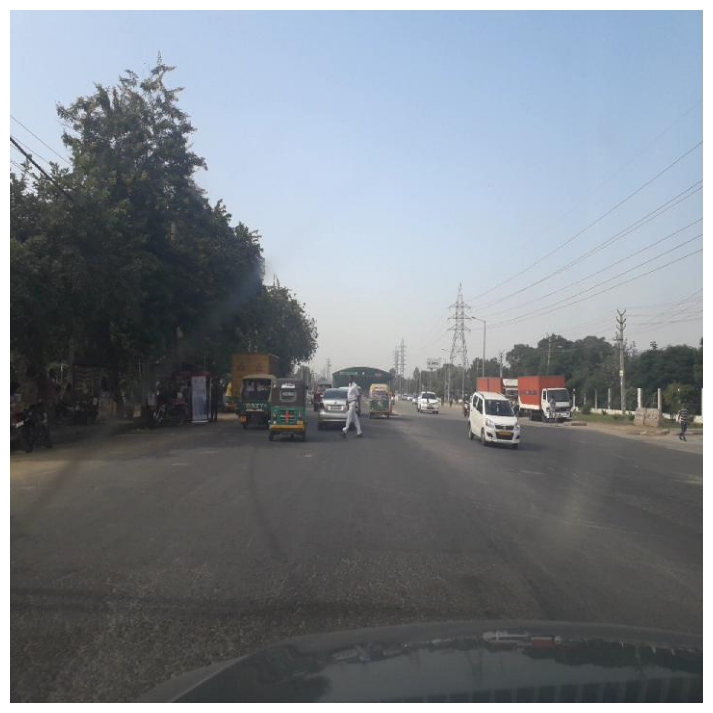

In [39]:
def show_yolo_image(image_path, label_path):

    image = cv2.imread(image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    h, w = image.shape[:2]

    plt.figure(figsize=(14, 9))

    plt.imshow(image)

    if os.path.exists(label_path):

        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:

            parts = line.strip().split()

            if len(parts) != 5:
                continue

            class_id = int(parts[0])

            x_center = float(parts[1]) * w
            y_center = float(parts[2]) * h

            box_width = float(parts[3]) * w
            box_height = float(parts[4]) * h

            x1 = x_center - box_width / 2
            y1 = y_center - box_height / 2

            plt.gca().add_patch(
                plt.Rectangle(
                    (x1, y1),
                    box_width,
                    box_height,
                    fill=False,
                    linewidth=2
                )
            )

            plt.text(
                x1,
                y1,
                CLASS_NAMES[class_id],
                fontsize=10,
                backgroundcolor="white"
            )

    plt.axis("off")
    plt.show()


train_images = glob.glob(
    os.path.join(
        INDIA_DATASET,
        "images",
        "train",
        "*.jpg"
    )
)

sample_image = random.choice(
    train_images
)

sample_label = os.path.join(
    INDIA_DATASET,
    "labels",
    "train",
    os.path.splitext(
        os.path.basename(sample_image)
    )[0] + ".txt"
)

print("Image:", sample_image)
print("Label:", sample_label)

show_yolo_image(
    sample_image,
    sample_label
)

In [40]:
class_counter = Counter()

for split in ["train", "val", "test"]:

    label_dir = os.path.join(
        INDIA_DATASET,
        "labels",
        split
    )

    label_files = glob.glob(
        os.path.join(label_dir, "*.txt")
    )

    for label_file in label_files:

        with open(label_file, "r") as f:

            for line in f:

                parts = line.strip().split()

                if len(parts) >= 5:

                    class_id = int(parts[0])

                    class_counter[class_id] += 1


print("Class distribution:")
print()

for class_id in sorted(class_counter):

    print(
        f"{class_id} - "
        f"{CLASS_NAMES[class_id]}: "
        f"{class_counter[class_id]}"
    )

Class distribution:

0 - Longitudinal Crack: 1555
1 - Transverse Crack: 68
2 - Alligator Crack: 2021
3 - Pothole: 1372
4 - Unknown Damage: 3187


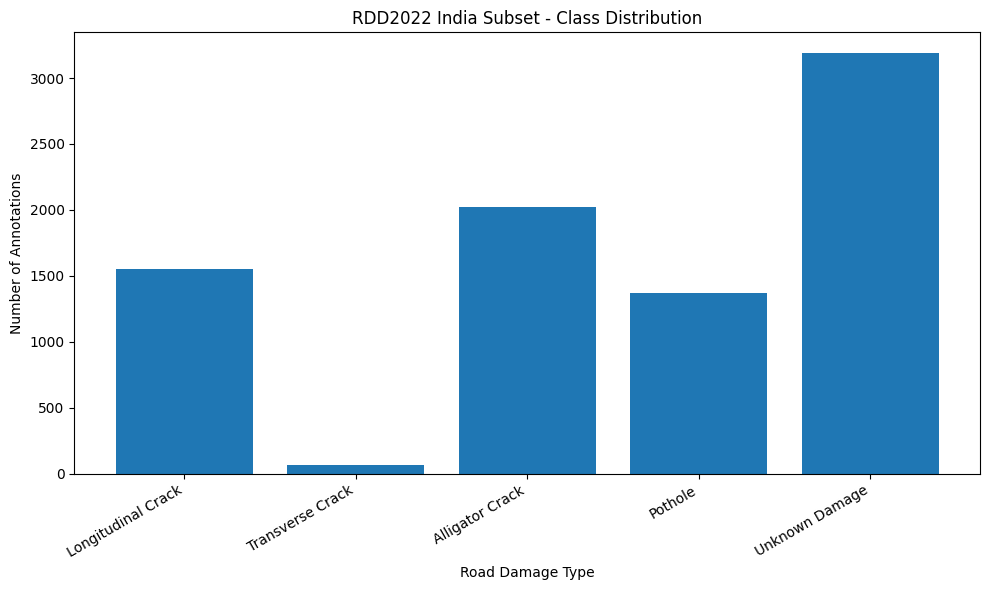

In [41]:
class_labels = [
    CLASS_NAMES[i]
    for i in sorted(class_counter)
]

class_values = [
    class_counter[i]
    for i in sorted(class_counter)
]

plt.figure(figsize=(10, 6))

plt.bar(
    class_labels,
    class_values
)

plt.title(
    "RDD2022 India Subset - Class Distribution"
)

plt.xlabel("Road Damage Type")
plt.ylabel("Number of Annotations")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()

In [42]:
model = YOLO("yolo26n.pt")

print("YOLO model loaded.")

YOLO model loaded.


In [ ]:
results = model.train(
    data=yaml_path,

    epochs=30,

    imgsz=640,

    batch=16,

    device=0,

    workers=2,

    patience=10,

    pretrained=True,

    project="/content/road_damage_training",

    name="rdd2022_india",

    verbose=True
)

New https://pypi.org/project/ultralytics/8.4.166 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.165 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/RDD2022_India_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt,

In [45]:
BEST_MODEL = (
    "/content/road_damage_training/"
    "rdd2022_india/weights/best.pt"
)

print("Best model:")
print(BEST_MODEL)

print(
    "Exists:",
    os.path.exists(BEST_MODEL)
)

Best model:
/content/road_damage_training/rdd2022_india/weights/best.pt
Exists: True


In [46]:
from IPython.display import Image, display

results_path = (
    "/content/road_damage_training/"
    "rdd2022_india/results.png"
)

if os.path.exists(results_path):

    display(
        Image(
            filename=results_path
        )
    )

else:

    print("Training results image not found.")

Training results image not found.


In [ ]:
trained_model = YOLO(
    BEST_MODEL
)

print("Best trained model loaded.")

In [ ]:
metrics = trained_model.val(
    data=yaml_path,
    split="val",
    imgsz=640,
    batch=16,
    device=0
)

In [ ]:
print("VALIDATION RESULTS")
print("=" * 50)

print(
    "mAP50:",
    round(metrics.box.map50, 4)
)

print(
    "mAP50-95:",
    round(metrics.box.map, 4)
)

print(
    "mAP75:",
    round(metrics.box.map75, 4)
)

print("\nPer-class mAP50-95:")

for class_id, score in enumerate(
    metrics.box.maps
):

    print(
        f"{CLASS_NAMES[class_id]:25s}: "
        f"{score:.4f}"
    )

In [ ]:
test_metrics = trained_model.val(
    data=yaml_path,
    split="test",
    imgsz=640,
    batch=16,
    device=0
)

In [ ]:
print("TEST SET RESULTS")
print("=" * 50)

print(
    "mAP50:",
    round(test_metrics.box.map50, 4)
)

print(
    "mAP50-95:",
    round(test_metrics.box.map, 4)
)

print(
    "mAP75:",
    round(test_metrics.box.map75, 4)
)

print("\nPer-class mAP50-95:")

for class_id, score in enumerate(
    test_metrics.box.maps
):

    print(
        f"{CLASS_NAMES[class_id]:25s}: "
        f"{score:.4f}"
    )

In [ ]:
test_images = glob.glob(
    os.path.join(
        INDIA_DATASET,
        "images",
        "test",
        "*.jpg"
    )
)

print(
    "India test images:",
    len(test_images)
)

test_image = random.choice(
    test_images
)

print(
    "Selected image:",
    test_image
)

In [ ]:
results = trained_model.predict(
    source=test_image,
    imgsz=640,
    conf=0.25,
    device=0,
    verbose=False
)

result = results[0]

annotated = result.plot()

annotated = cv2.cvtColor(
    annotated,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(16, 10))

plt.imshow(annotated)

plt.axis("off")

plt.title(
    "RDD2022 India - Road Damage Detection"
)

plt.show()

In [ ]:
def calculate_severity(
    class_name,
    area_ratio
):

    area_percentage = area_ratio * 100

    # Potholes
    if class_name == "Pothole":

        if area_percentage < 1:
            return "Low"

        elif area_percentage < 4:
            return "Medium"

        else:
            return "High"

    # Cracks
    else:

        if area_percentage < 0.5:
            return "Low"

        elif area_percentage < 2:
            return "Medium"

        else:
            return "High"

In [ ]:
def calculate_severity_score(
    class_name,
    area_ratio
):

    area_percentage = area_ratio * 100

    if class_name == "Pothole":

        if area_percentage < 1:
            score = 1

        elif area_percentage < 4:
            score = 2

        else:
            score = 3

    else:

        if area_percentage < 0.5:
            score = 1

        elif area_percentage < 2:
            score = 2

        else:
            score = 3

    return score

In [ ]:
def detect_road_damage(
    model,
    image_path,
    confidence_threshold=0.25
):

    image = cv2.imread(image_path)

    if image is None:

        raise ValueError(
            "Unable to read image."
        )

    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    image_height, image_width = image.shape[:2]

    image_area = (
        image_width *
        image_height
    )

    results = model.predict(
        source=image_path,
        imgsz=640,
        conf=confidence_threshold,
        device=0,
        verbose=False
    )

    result = results[0]

    detections = []

    if result.boxes is None:

        return image_rgb, detections

    for i in range(len(result.boxes)):

        box = (
            result.boxes.xyxy[i]
            .cpu()
            .numpy()
        )

        x1, y1, x2, y2 = box

        confidence = float(
            result.boxes.conf[i]
            .cpu()
            .numpy()
        )

        class_id = int(
            result.boxes.cls[i]
            .cpu()
            .numpy()
        )

        class_name = CLASS_NAMES[
            class_id
        ]

        box_width = max(
            0,
            x2 - x1
        )

        box_height = max(
            0,
            y2 - y1
        )

        box_area = (
            box_width *
            box_height
        )

        area_ratio = (
            box_area /
            image_area
        )

        severity = calculate_severity(
            class_name,
            area_ratio
        )

        severity_score = calculate_severity_score(
            class_name,
            area_ratio
        )

        detection = {

            "Defect":
                class_name,

            "Confidence":
                round(confidence, 3),

            "Severity":
                severity,

            "Severity Score":
                severity_score,

            "Defect Area (%)":
                round(
                    area_ratio * 100,
                    3
                ),

            "X1":
                int(x1),

            "Y1":
                int(y1),

            "X2":
                int(x2),

            "Y2":
                int(y2)
        }

        detections.append(
            detection
        )

        # Draw bounding box
        cv2.rectangle(
            image_rgb,

            (
                int(x1),
                int(y1)
            ),

            (
                int(x2),
                int(y2)
            ),

            (255, 0, 0),

            3
        )

        label = (
            f"{class_name} | "
            f"{severity} | "
            f"{confidence:.2f}"
        )

        # Calculate text size
        (
            text_width,
            text_height
        ), baseline = cv2.getTextSize(
            label,
            cv2.FONT_HERSHEY_SIMPLEX,
            0.65,
            2
        )

        text_y = max(
            int(y1) - 10,
            text_height + 10
        )

        # White text background
        cv2.rectangle(
            image_rgb,

            (
                int(x1),
                text_y - text_height - baseline
            ),

            (
                int(x1) + text_width,
                text_y + baseline
            ),

            (255, 255, 255),

            -1
        )

        # Text
        cv2.putText(
            image_rgb,

            label,

            (
                int(x1),
                text_y
            ),

            cv2.FONT_HERSHEY_SIMPLEX,

            0.65,

            (0, 0, 0),

            2
        )

    return image_rgb, detections

In [ ]:
final_image, detections = detect_road_damage(
    trained_model,
    test_image,
    confidence_threshold=0.25
)

plt.figure(figsize=(16, 10))

plt.imshow(final_image)

plt.axis("off")

plt.title(
    "Road Damage Detection and Severity Assessment"
)

plt.show()

In [ ]:
if len(detections) > 0:

    results_df = pd.DataFrame(
        detections
    )

    display(results_df)

else:

    print(
        "No road damage detected."
    )

In [ ]:
from google.colab import files

uploaded = files.upload()

new_image_path = list(
    uploaded.keys()
)[0]

print(
    "Uploaded image:",
    new_image_path
)

In [ ]:
new_image, new_detections = detect_road_damage(
    trained_model,
    new_image_path,
    confidence_threshold=0.25
)

plt.figure(figsize=(16, 10))

plt.imshow(new_image)

plt.axis("off")

plt.title(
    "Road Damage Detection + Severity"
)

plt.show()

In [ ]:
if len(new_detections) > 0:

    new_results_df = pd.DataFrame(
        new_detections
    )

    display(
        new_results_df
    )

else:

    print(
        "No road damage detected."
    )

In [ ]:
output_path = (
    "/content/"
    "road_damage_final_prediction.jpg"
)

output_bgr = cv2.cvtColor(
    new_image,
    cv2.COLOR_RGB2BGR
)

cv2.imwrite(
    output_path,
    output_bgr
)

print(
    "Saved:",
    output_path
)

In [ ]:
if len(new_detections) > 0:

    results_csv = (
        "/content/"
        "road_damage_results.csv"
    )

    pd.DataFrame(
        new_detections
    ).to_csv(
        results_csv,
        index=False
    )

    print(
        "CSV saved:",
        results_csv
    )

In [ ]:
from google.colab import files

files.download(
    BEST_MODEL
)

In [ ]:
files.download(
    "/content/"
    "road_damage_final_prediction.jpg"
)

                    RDD2022
                       │
                       ▼
             Filter India Images
                       │
                       ▼
              India YOLO Dataset
                       │
                       ▼
                YOLO26n Training
                       │
                       ▼
              Road Damage Detection
                       │
          ┌────────────┼────────────┐
          ▼            ▼            ▼
      Class         Bounding      Confidence
    Prediction        Box
          │
          ▼
   ┌──────┴─────────────────────┐
   │                             │
   ▼                             ▼
Pothole / Cracks          Relative Defect Area
                                 │
                                 ▼
                         Severity Assessment
                                 │
                    ┌────────────┼────────────┐
                    ▼            ▼            ▼
                   Low        Medium         High